In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import torch
from pathlib import Path

# ==============================
# Ruta del modelo
# ==============================

model_path = Path("/content/drive/MyDrive/PINN_experiments/exp_01_5000_epochs/model_run_001.pt")

Mounted at /content/drive


In [ ]:
# ==============================
# Cargar checkpoint
# ==============================

checkpoint = torch.load(model_path, map_location="cpu")

print("Contenido del checkpoint:")
print(checkpoint.keys())

print("\n")

# ==============================
# Extraer state_dict
# ==============================

state_dict = checkpoint["model_state_dict"]

print("Parámetros encontrados:\n")

for name in state_dict.keys():
    print(name)

print("\n==============================\n")

# ==============================
# Imprimir pesos y sesgos
# ==============================

for name, tensor in state_dict.items():

    print("="*70)
    print(f"Parámetro: {name}")
    print(f"Dimensión: {tuple(tensor.shape)}")
    print(f"Tipo: {tensor.dtype}")

    print("\nValores:\n")
    print(tensor)

    print("\n")

Contenido del checkpoint:
dict_keys(['model_state_dict', 'epoch', 'loss', 'max_error', 'success', 'history'])


Parámetros encontrados:

layers.0.weight
layers.0.bias
layers.1.weight
layers.1.bias
layers.2.weight
layers.2.bias
layers.3.weight
layers.3.bias
layers.4.weight
layers.4.bias


Parámetro: layers.0.weight
Dimensión: (50, 1)
Tipo: torch.float32

Valores:

tensor([[ 0.8366],
        [ 0.8772],
        [-0.1846],
        [ 0.9839],
        [-0.2639],
        [ 0.2056],
        [-0.4409],
        [ 0.6271],
        [ 0.9268],
        [-0.7751],
        [ 0.9051],
        [ 0.2413],
        [ 0.7809],
        [ 0.1912],
        [ 0.5154],
        [-0.1757],
        [ 0.8184],
        [ 0.1992],
        [-0.4742],
        [ 0.2470],
        [-0.5181],
        [-0.1606],
        [-0.4124],
        [ 0.7427],
        [-0.8503],
        [-0.5059],
        [-0.2491],
        [-0.6163],
        [ 0.0248],
        [-1.0520],
        [ 0.9317],
        [-0.8872],
        [ 0.8192],
       

In [ ]:
# =======================================================
# Importacion de librerías
# =======================================================

from google.colab import drive
drive.mount('/content/drive')
import torch
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from collections import defaultdict

Mounted at /content/drive


In [ ]:
# =======================================================
# Definición de rutas
# =======================================================

best_path = Path("/content/drive/MyDrive/PINN_experiments/exp_01_5000_epochs")

worst_path = Path("/content/drive/MyDrive/PINN_experiments/exp_09_10_neurons")

In [ ]:
# =======================================================
# Función para lectura de todos los modelos
# =======================================================

def load_all_weights(folder):

    weights = defaultdict(list)
    biases = defaultdict(list)

    files = sorted(folder.glob("model_run_*.pt"))

    print(f"Modelos encontrados: {len(files)}")

    for file in files:

        checkpoint = torch.load(file, map_location="cpu")

        state = checkpoint["model_state_dict"]

        for name, tensor in state.items():

            array = tensor.cpu().numpy().flatten()

            if "weight" in name:
                weights[name].extend(array)

            elif "bias" in name:
                biases[name].extend(array)

    return weights, biases

In [ ]:
# =======================================================
# Carga del mejor y peor experimento
# =======================================================

best_weights, best_biases = load_all_weights(best_path)

worst_weights, worst_biases = load_all_weights(worst_path)

Modelos encontrados: 100
Modelos encontrados: 16


In [ ]:
# =======================================================
# Estadísticos descriptivos
# =======================================================

def print_statistics(data, title):

    print("="*70)
    print(title)
    print("="*70)

    for name, values in data.items():

        values = np.array(values)

        print(f"\n{name}")

        print(f"Cantidad      : {len(values)}")
        print(f"Media         : {np.mean(values):.6f}")
        print(f"Desv. estándar: {np.std(values):.6f}")
        print(f"Mínimo        : {np.min(values):.6f}")
        print(f"Máximo        : {np.max(values):.6f}")
        print(f"Mediana       : {np.median(values):.6f}")
        print(f"Norma L2      : {np.linalg.norm(values):.6f}")


print_statistics(best_weights, "MEJOR ARQUITECTURA - PESOS")

print_statistics(best_biases, "MEJOR ARQUITECTURA - SESGOS")

print_statistics(worst_weights, "PEOR ARQUITECTURA - PESOS")

print_statistics(worst_biases, "PEOR ARQUITECTURA - SESGOS")




MEJOR ARQUITECTURA - PESOS

layers.0.weight
Cantidad      : 5000
Media         : 0.003297
Desv. estándar: 0.610996
Mínimo        : -1.096449
Máximo        : 1.084255
Mediana       : -0.000393
Norma L2      : 43.204567

layers.1.weight
Cantidad      : 250000
Media         : 0.000086
Desv. estándar: 0.092441
Mínimo        : -0.303875
Máximo        : 0.303397
Mediana       : 0.000231
Norma L2      : 46.220646

layers.2.weight
Cantidad      : 250000
Media         : -0.000059
Desv. estándar: 0.093710
Mínimo        : -0.316109
Máximo        : 0.326652
Mediana       : 0.000045
Norma L2      : 46.855221

layers.3.weight
Cantidad      : 250000
Media         : -0.000062
Desv. estándar: 0.095943
Mínimo        : -0.299720
Máximo        : 0.307756
Mediana       : -0.000068
Norma L2      : 47.971741

layers.4.weight
Cantidad      : 5000
Media         : 0.000833
Desv. estándar: 0.118986
Mínimo        : -0.253138
Máximo        : 0.226903
Mediana       : 0.008769
Norma L2      : 8.413766
MEJOR ARQUITEC

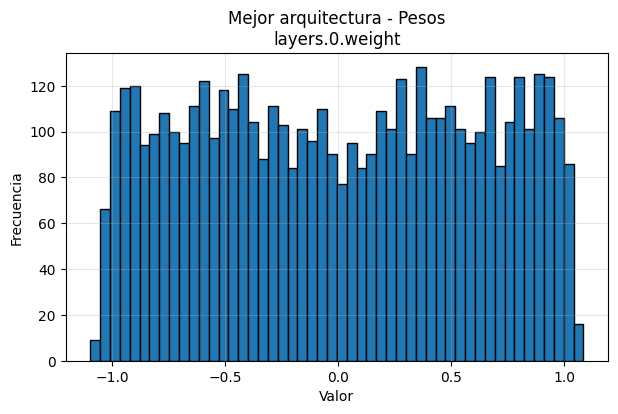

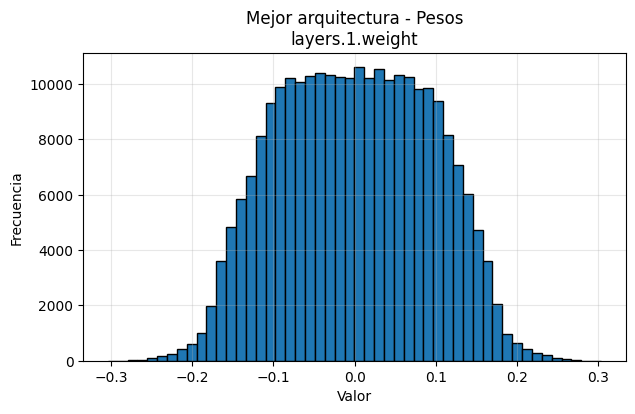

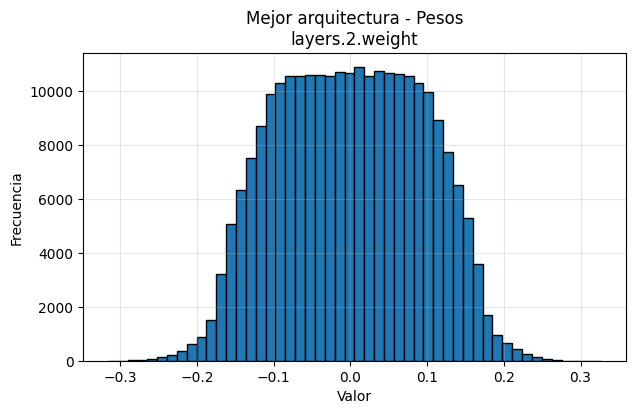

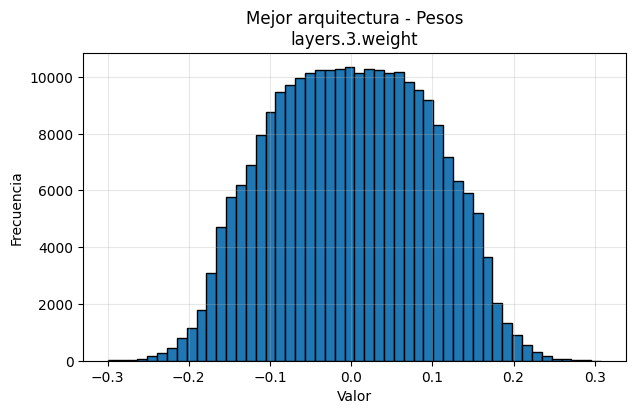

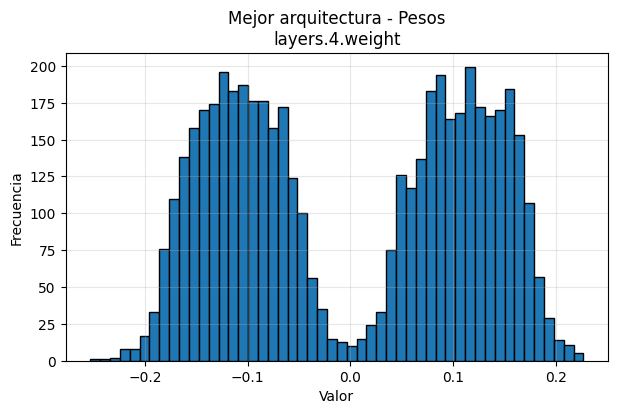

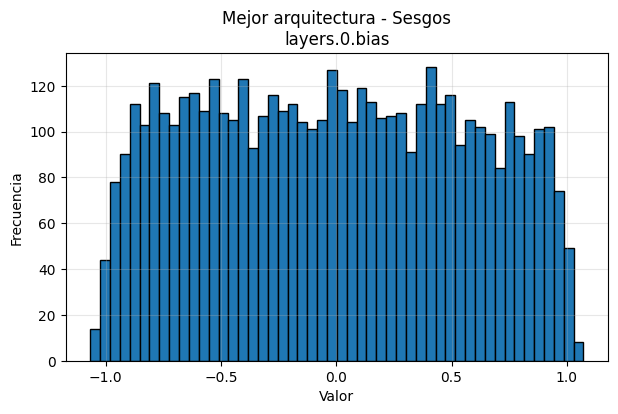

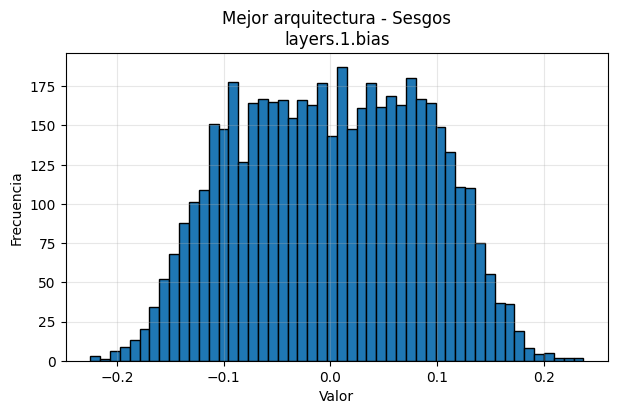

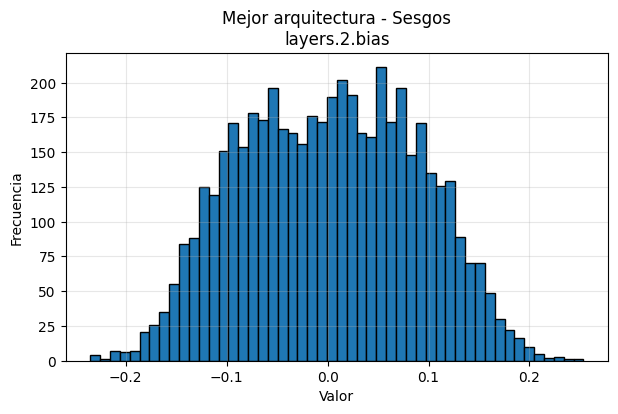

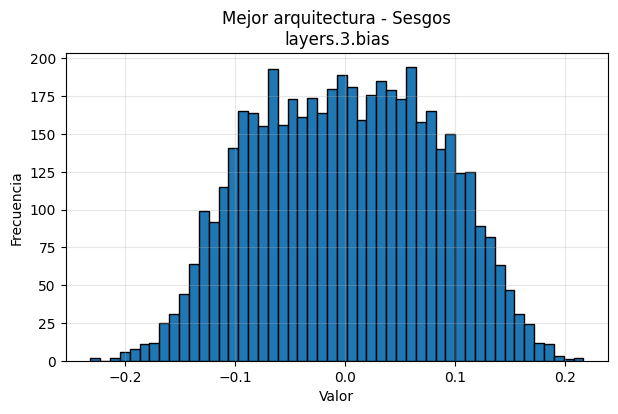

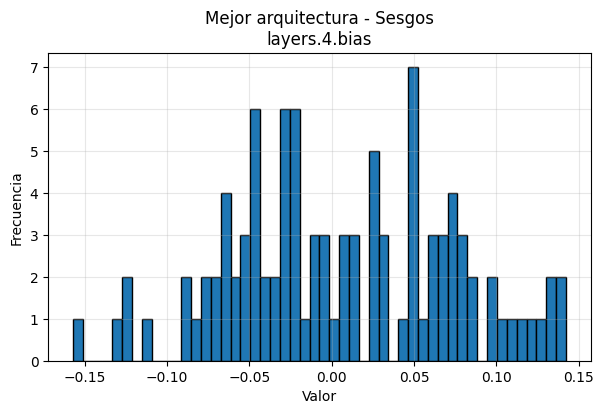

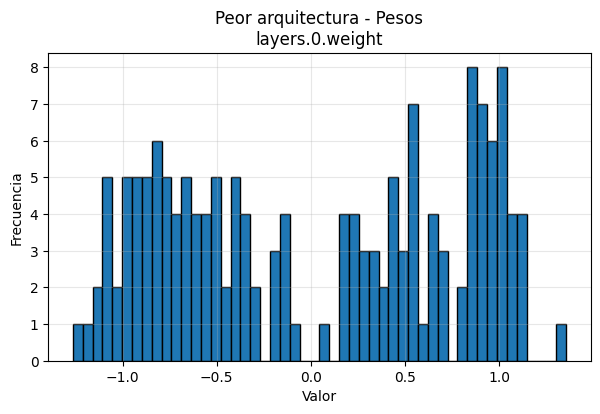

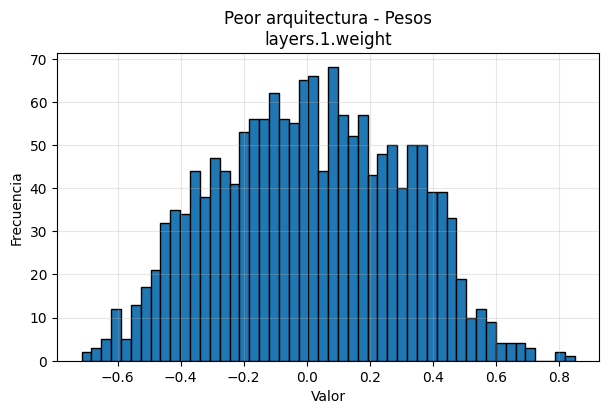

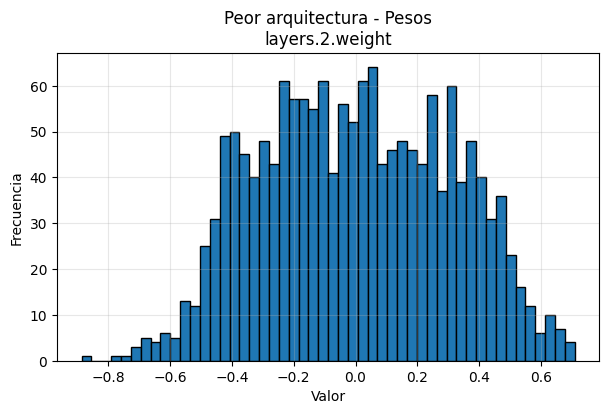

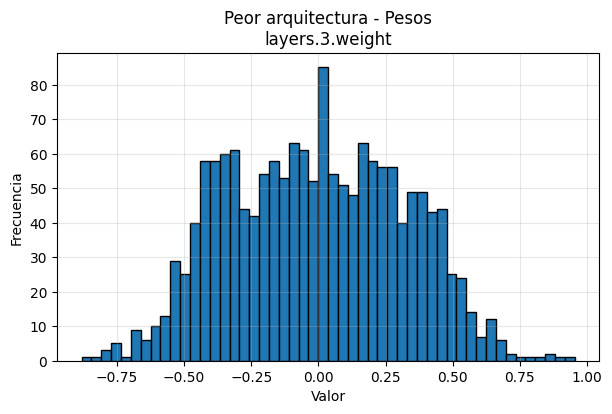

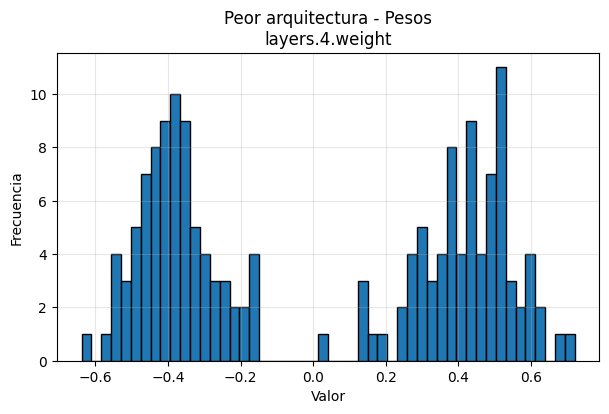

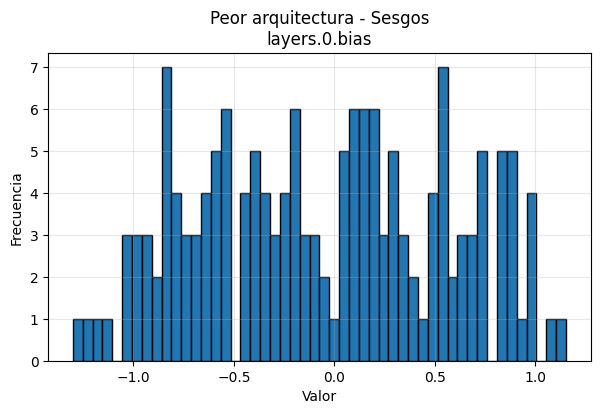

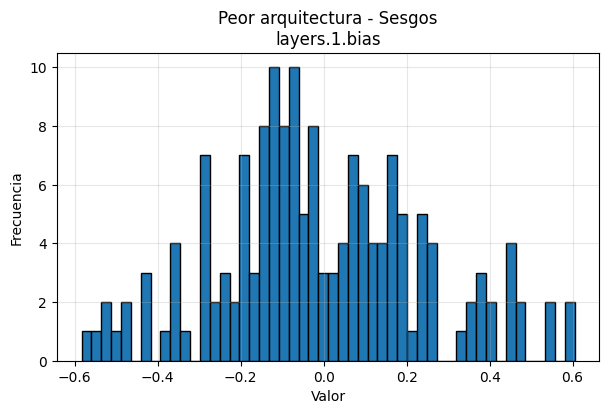

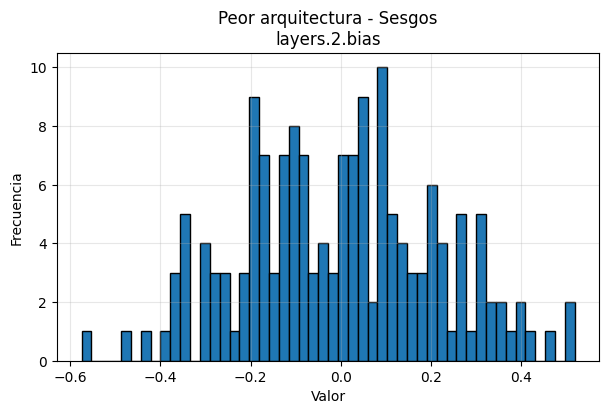

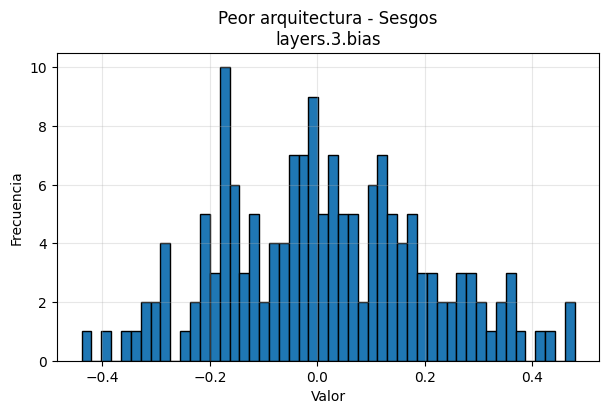

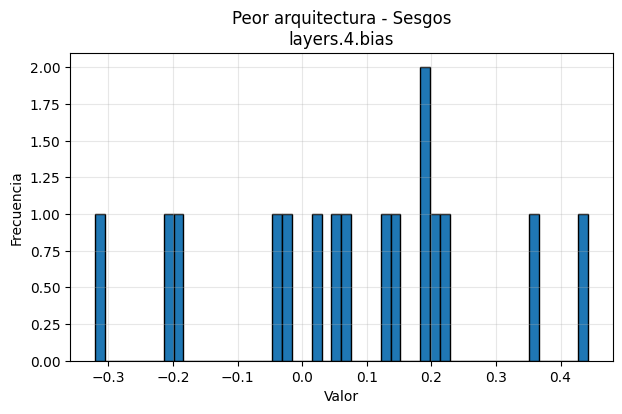

In [ ]:
# =======================================================
# Histogramas
# =======================================================

def plot_histograms(data, title):

    for name, values in data.items():

        plt.figure(figsize=(7,4))

        plt.hist(values,
                 bins=50,
                 edgecolor="black")

        plt.title(f"{title}\n{name}")

        plt.xlabel("Valor")

        plt.ylabel("Frecuencia")

        plt.grid(alpha=0.3)

        plt.show()


# Graficación
plot_histograms(best_weights,"Mejor arquitectura - Pesos")

plot_histograms(best_biases,"Mejor arquitectura - Sesgos")

plot_histograms(worst_weights,"Peor arquitectura - Pesos")

plot_histograms(worst_biases,"Peor arquitectura - Sesgos")


In [ ]:
# =======================================================
# Comparación entre mejor y peor experimento
# =======================================================

def compare_histograms(best,
                       worst,
                       parameter):

    plt.figure(figsize=(8,5))

    plt.hist(best,
             bins=60,
             alpha=0.5,
             density=True,
             label="Mejor")

    plt.hist(worst,
             bins=60,
             alpha=0.5,
             density=True,
             label="Peor")

    plt.title(parameter)

    plt.xlabel("Valor")

    plt.ylabel("Densidad")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.show()

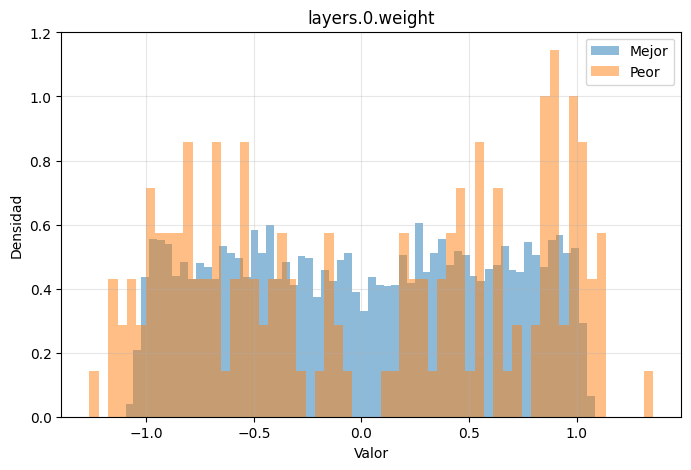

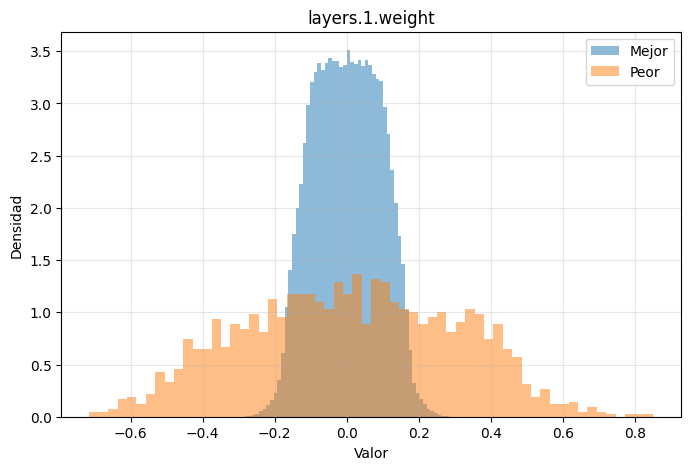

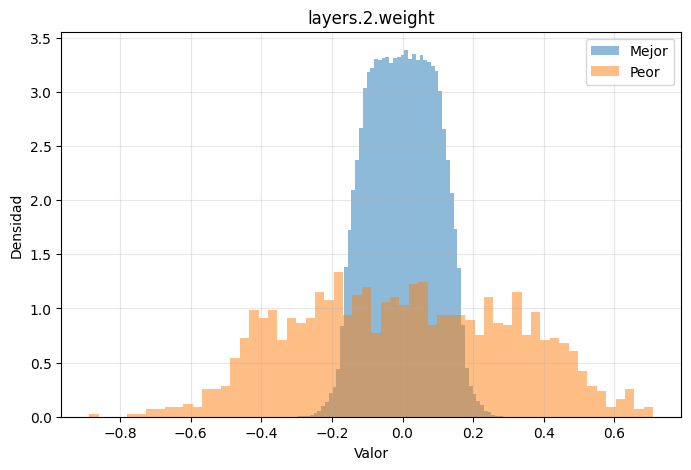

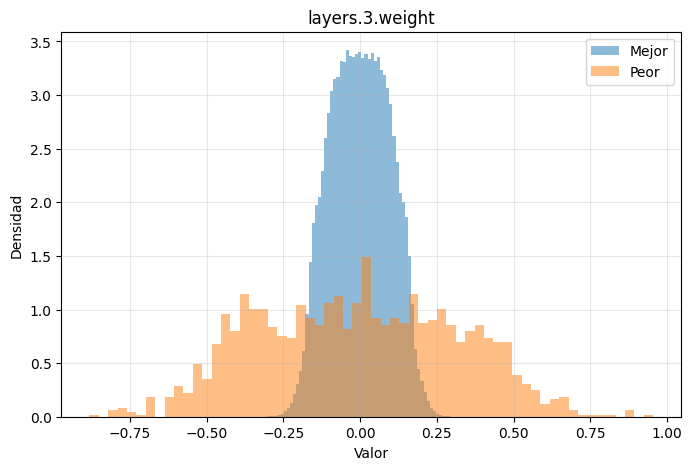

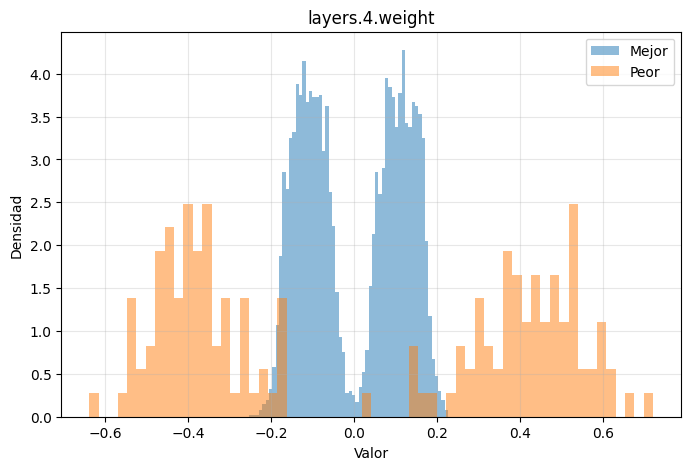

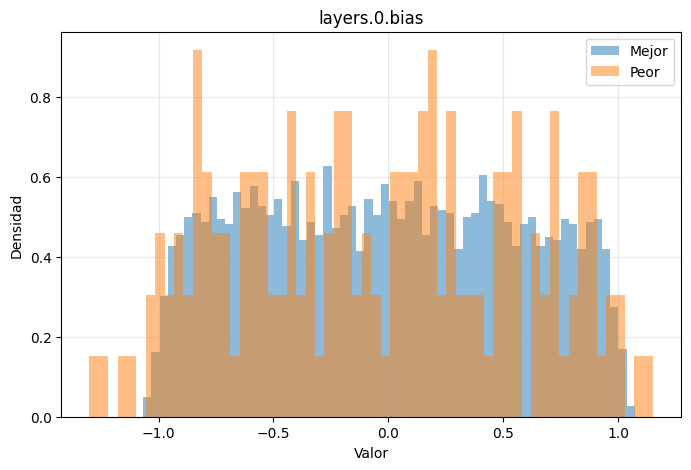

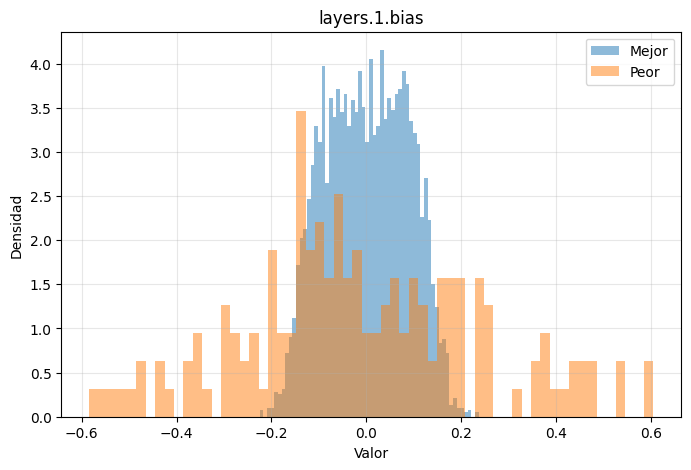

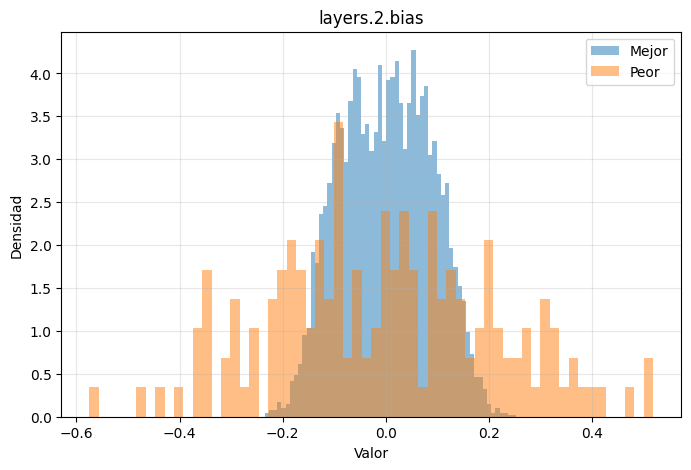

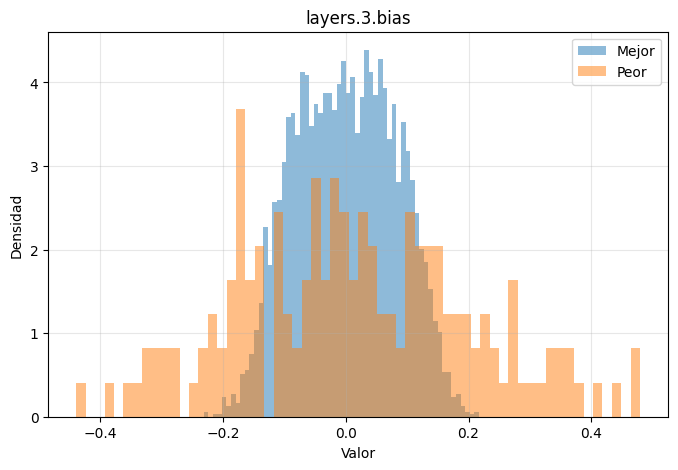

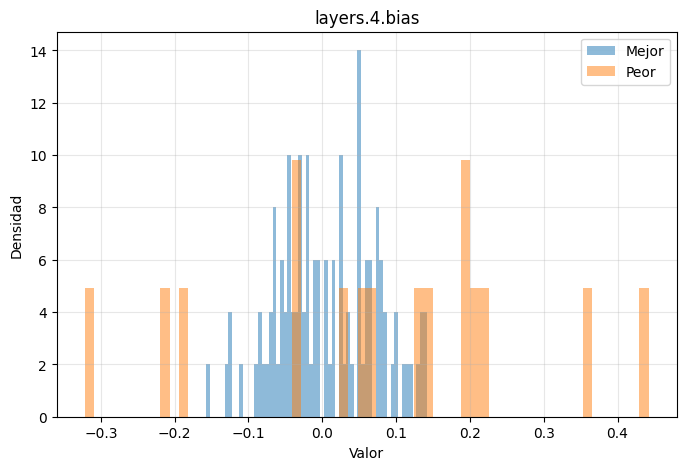

In [ ]:
# =======================================================
# Comparación capa por capa
# =======================================================

for layer in best_weights.keys():

    compare_histograms(
        best_weights[layer],
        worst_weights[layer],
        layer
    )


for layer in best_biases.keys():

    compare_histograms(
        best_biases[layer],
        worst_biases[layer],
        layer
    )